# 12. Forecast conditioning and the daily-shape prior

> **Companion to Notebook 11.** Notebook 11 found and fixed the MPC bug
> (`observe_present` churning the forecast residual) and showed the fix works.
> This notebook answers the *deeper* question that investigation kept running
> into: **what does the price forecaster actually do with the present, and why
> can it never anticipate a spike?** The answer — a strong prior on the daily
> *shape*, with the recent value setting only the *level* — is what makes the
> spike-gated controller both necessary and sufficient.

This report is the consolidated record of that investigation: each claim is a
plot, and several plots overturned an earlier, sloppier explanation. The
method matters as much as the result — **measure before concluding.**

## Objectives

1. Test whether the forecast the MPC plans on **conditions on the present** at all.
2. Show what a genuinely present-conditioned (lag-1) forecast looks like, and why
   even it **cannot anticipate a spike**.
3. Decompose the forecast into a **daily-shape prior** plus a **level** term, and
   measure how each responds to a constant bias vs zero-mean noise on the input.
4. Quantify the **shrinkage of the input toward the prior**, and check it against
   the truth to see whether that shrinkage is correct.
5. State precisely what remains **unexplained**.

## Prerequisites
Notebook 08 (the quantile fan), Notebook 11 (the MPC bug + fix), and the cached
30-min fans under `outputs/testbed/fans/`.

In [1]:
import os
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from grian.config import repo_root
from grian.viz import apply_style, save_fig

os.chdir(repo_root())
apply_style()

sys.path.insert(0, str(repo_root() / "scripts"))
import testbed as tb

tb.RESOLUTION, tb.HORIZON = "30min", 48
from grian.sim.mpc import _forecast_from_fan

df = pd.read_parquet(repo_root() / "data" / "processed" / "SA1_30min_sim.parquet")
price = df["price"]
hour = df.index.hour + df.index.minute / 60.0
dow = df.index.dayofweek
y = np.arcsinh(price.values)                          # model the compressed target

TRAIN = (df.index >= "2023-06-01") & (df.index < "2025-06-30")
def _fit(cols):
    X = pd.DataFrame(cols, index=df.index)
    m = X.notna().all(axis=1).values & TRAIN
    mdl = lgb.LGBMRegressor(n_estimators=350, learning_rate=0.05, num_leaves=31,
                            min_child_samples=40, verbosity=-1).fit(X[m], y[m])
    return mdl, X

# Shared models (trained once, reused below):
#  FULL  : 1-step forecast that SEES the present (lag-1,-2,-3) + daily/weekly + calendar
#  PRIOR : the daily-shape prior only (lag-48, lag-week, calendar) -- no recent value
recent = dict(seen0=price.shift(1), seen1=price.shift(2), seen2=price.shift(3))
prior_cols = dict(day=price.shift(48), week=price.shift(336), hour=hour, dow=dow)
FULL,  Xfull  = _fit({**recent, **prior_cols})
PRIOR, Xprior = _fit(prior_cols)
print("models trained. train window:", "2023-06 -> 2025-06;  everything below is out-of-sample.")

models trained. train window: 2023-06 -> 2025-06;  everything below is out-of-sample.


---
## 1. Does the forecast even condition on the present?

The controller plans the battery on a **multi-step** forecast (the next 24 h). A
clean test: take one fixed evening window and forecast it at several **lead
times**. If the forecast conditions on recent data, a short-lead forecast should
beat a long-lead one. We use the actual `lightgbm_qmean` fan the MPC consumes.

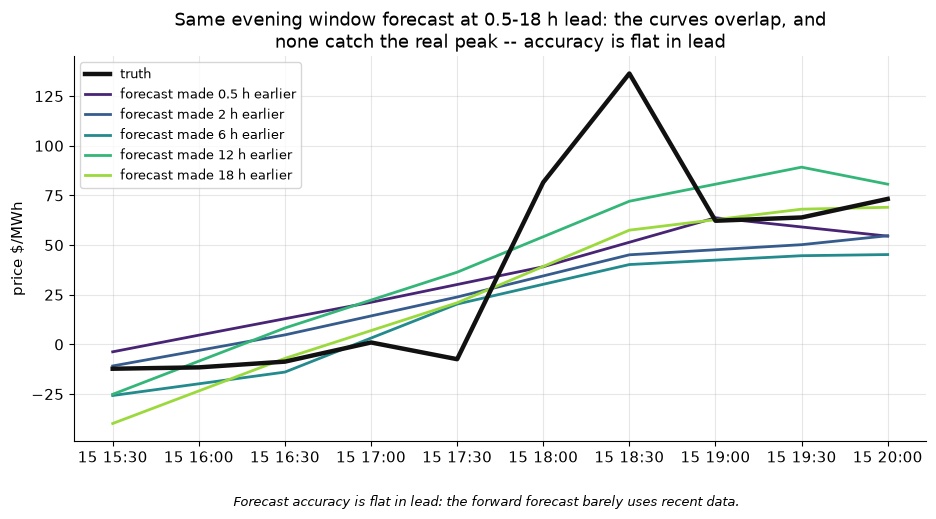

In [2]:
fan = tb._load_fans(tb._fan_path("lightgbm_qmean", "calm_sep25"))
def qmean_path(origin):                               # 48-step point path, dollars
    return _forecast_from_fan(fan[origin], "point", 0.1, 0.9)

W0 = pd.Timestamp("2025-09-15 15:30"); W = 10
win = pd.date_range(W0, periods=W, freq="30min")
truth = price.reindex(win)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(win, truth.values, color="#111", lw=3.2, label="truth", zorder=10)
for lead, c in zip([0.5, 2, 6, 12, 18], plt.cm.viridis(np.linspace(0.1, 0.85, 5))):
    steps = int(round(lead * 2))
    seg = qmean_path(W0 - pd.Timedelta(hours=lead))[steps: steps + W]
    ax.plot(win, seg, color=c, lw=2, label=f"forecast made {lead:g} h earlier")
ax.set_ylabel("price $/MWh")
ax.set_title("Same evening window forecast at 0.5-18 h lead: the curves overlap, and\n"
             "none catch the real peak -- accuracy is flat in lead")
ax.legend(loc="upper left", fontsize=9)
save_fig(fig, "nb12_lead", "Forecast accuracy is flat in lead: the forward forecast barely uses recent data.")
plt.show()

**Reading.** All the lines collapse onto the same smooth *typical-evening* ramp,
and a forecast made 18 h ahead is as good as one made 30 min ahead. So for its
**forward horizon** — the part the controller plans on — this model barely
conditions on the present. (Its *step-0 nowcast* does track the present via a
1-hour rolling-mean feature, ~0.90 correlation; but that is one step, not the
plan.)

---
## 2. What a present-conditioned forecast looks like — and why it still can't
anticipate a spike

Now a **rolling fixed-lead** forecast: for each `t`, `f(t)` is allowed to see the
truth only up to `t - k`. `k = 1` is "conditioned on lag-1" — it sees `GT(t-1)`.

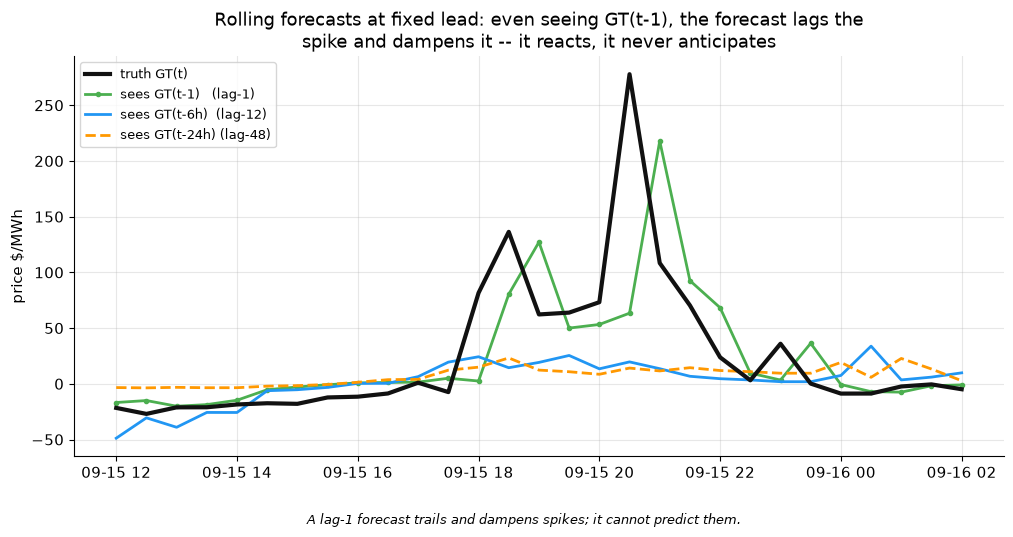

In [3]:
def rolling(k):
    # f(t) = prediction of price[t] using ONLY prices at or before t-k
    cols = dict(seen0=price.shift(k), seen1=price.shift(k + 1), seen2=price.shift(k + 2),
                day=price.shift(max(k, 48)), week=price.shift(max(k, 336)),
                hour=hour, dow=dow)
    mdl, X = _fit(cols)
    return pd.Series(np.sinh(mdl.predict(X)), index=df.index)

f1, f12, f48 = rolling(1), rolling(12), rolling(48)
V = slice("2025-09-15 12:00", "2025-09-16 02:00"); t = price.loc[V]
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(t.index, t.values, color="#111", lw=3, label="truth GT(t)", zorder=10)
ax.plot(t.index, f1.loc[V],  color="#4CAF50", lw=2, marker="o", ms=3, label="sees GT(t-1)   (lag-1)")
ax.plot(t.index, f12.loc[V], color="#2196F3", lw=2, label="sees GT(t-6h)  (lag-12)")
ax.plot(t.index, f48.loc[V], color="#FF9800", lw=2, ls="--", label="sees GT(t-24h) (lag-48)")
ax.set_ylabel("price $/MWh")
ax.set_title("Rolling forecasts at fixed lead: even seeing GT(t-1), the forecast lags the\n"
             "spike and dampens it -- it reacts, it never anticipates")
ax.legend(loc="upper left", fontsize=9)
save_fig(fig, "nb12_rolling", "A lag-1 forecast trails and dampens spikes; it cannot predict them.")
plt.show()

**Reading.** The green line (sees `GT(t-1)`) tracks the calm stretches but at each
spike it **lags one step and dampens hard** — when the truth hits ~$278 it reaches
only ~$87, one interval late. A spike at `t` is simply **not predictable from
`GT(t-1)`**: spikes come from unit trips and bidding, not the recent price path.
The best any forecast can do at a spike is "roughly persist/revert," which
under-shoots. This is an **information limit**, not a weak model.

---
## 3. The forecast = a daily-shape *prior* + a *level*

Hypothesis: the forecast holds a strong prior on the daily **shape**, and the
recent value sets the **level**. Test it by offsetting the recent input by a
constant bias and watching whether the shape survives.

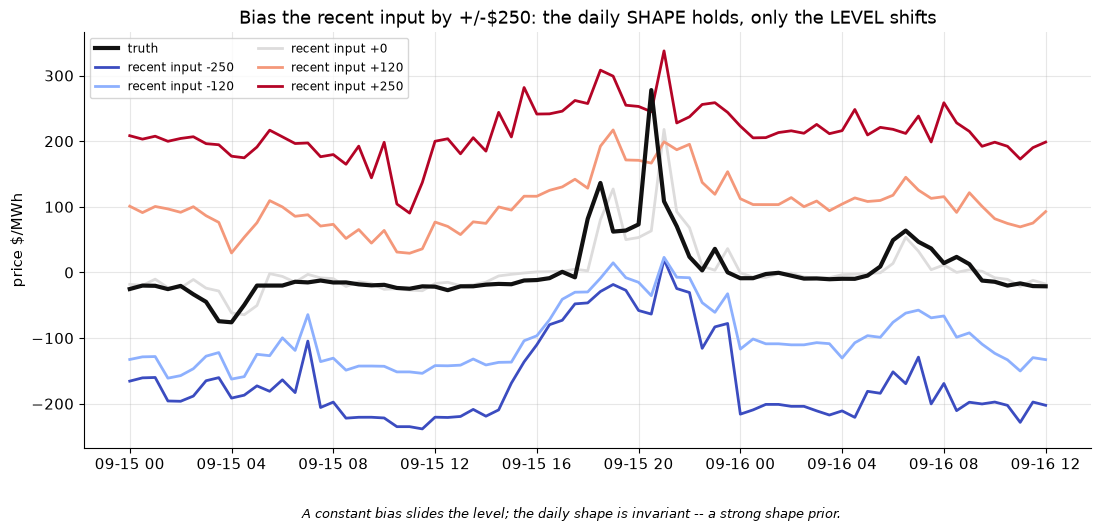

In [4]:
RECENT = ["seen0", "seen1", "seen2"]
Vp = slice("2025-09-15 00:00", "2025-09-16 12:00")
base = Xfull.loc[Vp].copy(); tr = price.loc[Vp]
fig, ax = plt.subplots(figsize=(13, 5.4))
ax.plot(tr.index, tr.values, color="#111", lw=3, label="truth", zorder=10)
for off, c in zip([-250, -120, 0, 120, 250], plt.cm.coolwarm(np.linspace(0, 1, 5))):
    fp = base.copy(); fp[RECENT] = fp[RECENT] + off
    ax.plot(tr.index, np.sinh(FULL.predict(fp)), color=c, lw=2,
            label=f"recent input {'+' if off>=0 else ''}{off}")
ax.set_ylabel("price $/MWh")
ax.set_title("Bias the recent input by +/-$250: the daily SHAPE holds, only the LEVEL shifts")
ax.legend(loc="upper left", fontsize=8.5, ncol=2)
save_fig(fig, "nb12_prior_bias", "A constant bias slides the level; the daily shape is invariant -- a strong shape prior.")
plt.show()

**Reading.** The five curves are the **same daily shape shifted vertically**. The
recent value controls *where the curve sits*; the *shape* (evening peaks,
overnight troughs) is a strong prior from `lag-48` / calendar. Sensitivity is
about **0.65** $ of level per $ of input.

### 3.1 Bias vs Gaussian noise
A constant bias can only slide the level, so it cannot corrupt the shape *by
construction*. Zero-mean **per-interval noise** is the real robustness test.

sigma  30 -> forecast jitter std  26.9  (0.90x)
sigma  75 -> forecast jitter std  60.7  (0.81x)
sigma 150 -> forecast jitter std 134.2  (0.89x)


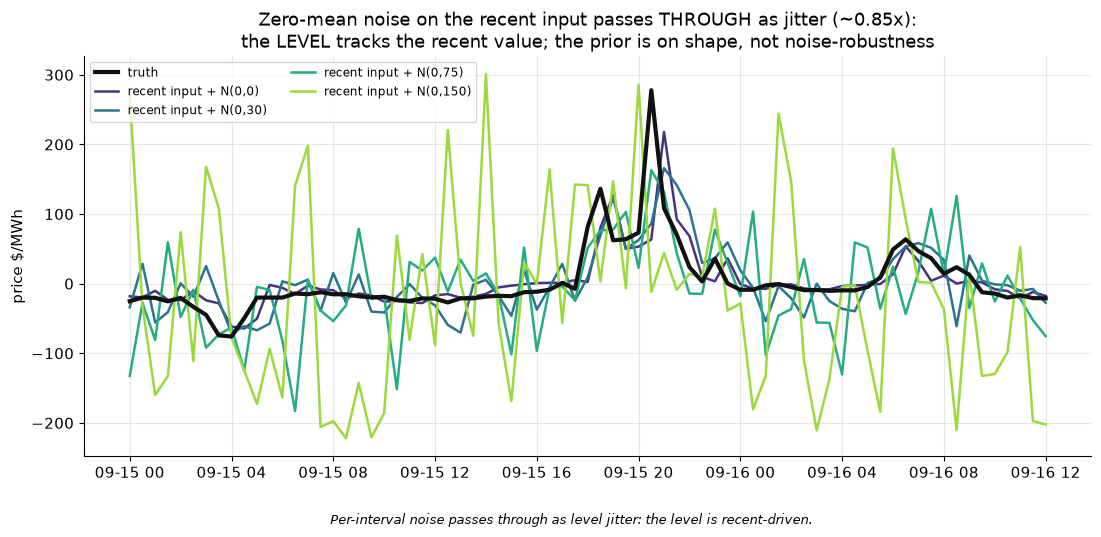

In [5]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(tr.index, tr.values, color="#111", lw=3, label="truth", zorder=10)
clean = np.sinh(FULL.predict(base))
for sig, c in zip([0, 30, 75, 150], plt.cm.viridis(np.linspace(0.15, 0.85, 4))):
    fp = base.copy(); eps = rng.normal(0, sig, len(fp))
    for col in RECENT: fp[col] = fp[col] + eps
    f = np.sinh(FULL.predict(fp))
    ax.plot(tr.index, f, color=c, lw=1.8, label=f"recent input + N(0,{sig})")
    if sig: print(f"sigma {sig:3d} -> forecast jitter std {np.std(f-clean):5.1f}  ({np.std(f-clean)/sig:.2f}x)")
ax.set_ylabel("price $/MWh")
ax.set_title("Zero-mean noise on the recent input passes THROUGH as jitter (~0.85x):\n"
             "the LEVEL tracks the recent value; the prior is on shape, not noise-robustness")
ax.legend(loc="upper left", fontsize=8.5, ncol=2)
save_fig(fig, "nb12_prior_noise", "Per-interval noise passes through as level jitter: the level is recent-driven.")
plt.show()

**Reading.** Noise **passes through** (~0.85x) — the forecast jitters. So the
*level* is genuinely recent-driven; it is not smoothed away. The strong prior is
specifically on the **shape**, not a claim that recent info is ignored. Together:

> **forecast(t) ≈ daily-shape-prior(t) + level(t),  level ≈ 0.7 × recent input.**

---
## 4. Shrinkage of the input toward the prior — and is it correct?

The sharpest test of "the model smooths values toward its daily prior": per
interval, compare the input's deviation from the prior, `X - P`, to the
prediction's deviation, `F - P`. If the model shrinks, `F - P` has the same sign
as `X - P` but smaller magnitude. We also plot the **truth**, `A - P`, to see
whether any shrinkage reflects real mean-reversion or is an artifact.

prediction on SAME side of prior as input : 93.6%
prediction magnitude SMALLER than input   : 67.7%
slope body  (|X-P| small) F vs X : 0.83
slope tail  (spikes)      F vs X : 0.12


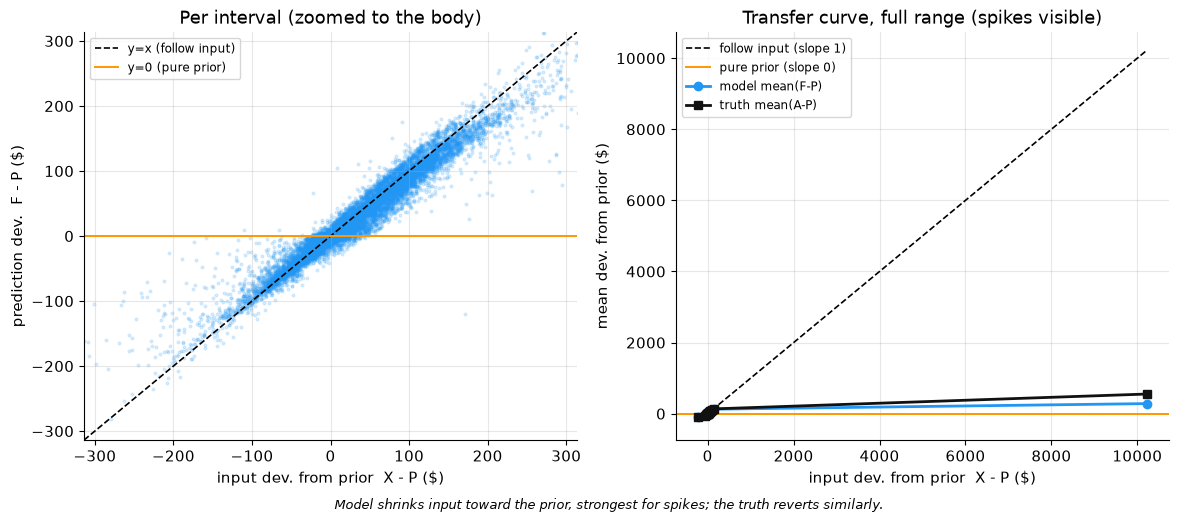

In [6]:
TEST = (df.index >= "2025-07-01") & Xfull.notna().all(axis=1).values
P = np.sinh(PRIOR.predict(Xfull[TEST][list(prior_cols)]))
F = np.sinh(FULL.predict(Xfull[TEST]))
X = price.shift(1).values[TEST]          # recent input value
A = price.values[TEST]                    # actual
dX, dF, dA = X - P, F - P, A - P

print(f"prediction on SAME side of prior as input : {np.mean(np.sign(dF)==np.sign(dX)):.1%}")
print(f"prediction magnitude SMALLER than input   : {np.mean(np.abs(dF)<np.abs(dX)):.1%}")
print(f"slope body  (|X-P| small) F vs X : {np.polyfit(dX[np.abs(dX)<np.percentile(np.abs(dX),50)], dF[np.abs(dX)<np.percentile(np.abs(dX),50)],1)[0]:.2f}")
big = dX > np.percentile(dX, 90)
print(f"slope tail  (spikes)      F vs X : {np.polyfit(dX[big], dF[big],1)[0]:.2f}")

bins = np.unique(np.quantile(dX, np.linspace(0, 1, 21)))
mid = 0.5*(bins[:-1]+bins[1:]); idx = np.clip(np.digitize(dX, bins)-1, 0, len(mid)-1)
mF = np.array([dF[idx==b].mean() for b in range(len(mid))])
mA = np.array([dA[idx==b].mean() for b in range(len(mid))])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(14, 5.3))
lim = np.percentile(np.abs(dX), 99)
a0.scatter(dX, dF, s=4, alpha=0.15, color="#2196F3")
a0.plot([-lim, lim], [-lim, lim], "k--", lw=1.2, label="y=x (follow input)")
a0.axhline(0, color="#FF9800", lw=1.4, label="y=0 (pure prior)")
a0.set_xlim(-lim, lim); a0.set_ylim(-lim, lim)
a0.set_xlabel("input dev. from prior  X - P ($)"); a0.set_ylabel("prediction dev.  F - P ($)")
a0.set_title("Per interval (zoomed to the body)"); a0.legend(loc="upper left", fontsize=8.5)
a1.plot(mid, mid, "k--", lw=1.2, label="follow input (slope 1)")
a1.axhline(0, color="#FF9800", lw=1.4, label="pure prior (slope 0)")
a1.plot(mid, mF, "o-", color="#2196F3", lw=2, label="model mean(F-P)")
a1.plot(mid, mA, "s-", color="#111", lw=2, label="truth mean(A-P)")
a1.set_xlabel("input dev. from prior  X - P ($)"); a1.set_ylabel("mean dev. from prior ($)")
a1.set_title("Transfer curve, full range (spikes visible)"); a1.legend(loc="upper left", fontsize=8.5)
save_fig(fig, "nb12_shrink", "Model shrinks input toward the prior, strongest for spikes; the truth reverts similarly.")
plt.show()

**How to read the left panel.** Each dot is one interval. The **dashed** line is
"the model deviates from the prior exactly as much as the input did" (follows the
input, no shrinkage); the **orange** line is "the model ignores the input and
predicts the prior" (full shrinkage). A dot's height between them is how much the
model kept vs pulled back. Near the origin the cloud hugs the diagonal (ordinary
deviations are followed, slope ~0.83); moving right it **sags toward the orange
line** — bigger deviations are pulled back harder. (Real spikes, `X-P` up to
~$10,000, are off this zoomed frame — that is what the right panel is for.)

**Right panel — the verdict.** The model (blue) shrinks hard: a **$10,000** input
deviation predicts only **~$300** above prior. But the **truth** (black) does the
same — an actual $10,000 deviation is followed by only **~$600** above prior on
average. So the shrinkage is **mostly correct**: spikes are one-interval events
that genuinely revert. The model reverts slightly *more* than reality (possible
mild over-shrinkage), but the dominant fact is real mean-reversion.

---
## What we established

1. The forward forecast the controller plans on is a **strong daily-shape prior**;
   its accuracy is flat in lead (Section 1).
2. Even a forecast that sees `GT(t-1)` only **reacts** to a spike, lagged and
   dampened — no forecast **anticipates** spikes (Section 2).
3. The forecast decomposes as **prior-shape + level**, where a bias slides the
   level cleanly but noise corrupts it (Section 3): the prior is on *shape*.
4. The model **shrinks input deviations toward the prior, most aggressively for
   spikes**, and that shrinkage **matches the truth** — spikes really do revert
   (Section 4).

**Why this matters for the controller.** A spike is a *shape* deviation, and the
forecast has no lever to bend the shape — it can only shift the level. So the
plan is always smooth, and the *only* moment the true present carries decisive,
non-prior information is **during** a spike. That is exactly what the spike-gated
`observe` in Notebook 11 exploits: react to the present only when it is a genuine
spike, and stay on the (correct, mean-reverting) plan otherwise.

---
## Open question (not yet explained)

We now understand the **forecast**. We do **not** yet fully understand the
**controller** in one respect:

> Using the model's predictions in a **nowcasting / frequent-reforecast** mode
> underperforms using them as a committed **day-ahead** plan — even with
> `observe_present` off (Notebook 11: `reforecast=1, resolve=1, observe=off`
> scored **0.437** vs open-loop **0.539**).

`observe_present` is explained (the step-0 discontinuity). But this *residual*
reforecast penalty is not. Given what we now know — the forecast is
prior-shape + a level that jitters with recent input (Section 3.1) — a plausible
next hypothesis is that **frequent reforecasting re-levels the near-term of the
plan every step, shifting the charge/discharge *ordering* the LP arbitrages, so
the plan churns even though the day-ahead shape is stable.** The next experiment
should test that directly: measure how much the LP's *action ordering* changes
between consecutive reforecasts, and whether it tracks the near-term level jitter.